In [16]:
# Fix sys path to find modules in the project
import sys
sys.path.append("/Users/gccasini/GitHub/diplomatrixbr-eval")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [ ]:
from scripts.utils import get_mean

import base64
import io
from IPython.display import HTML
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
import yaml

In [18]:
filepath = "/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/sheets/sabia_p7-12.csv"

df_eval = get_mean(filepath)
df_eval["nota_final"] = df_eval["nota_final"].fillna(df_eval["faixa"])
df_eval.drop(columns=["faixa"], inplace=True)

df_eval[:24]

,judge,prompt,temp,redacao,nota_final,1A,1B,1C,CGPL,num_errors
0,sabia-3.1,7,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000
1,sabia-3.1,7,0.5,1,52.6333,8.6667,8.6667,18.0000,17.3000,2.3333
2,sabia-3.1,7,0.9,1,51.6333,8.6667,9.0000,17.3333,16.6333,2.3333
3,sabia-3.1,8,0.0,1,55.7500,NaN,NaN,NaN,NaN,0.0000
4,sabia-3.1,8,0.5,1,57.2500,NaN,NaN,NaN,NaN,0.3333
5,sabia-3.1,8,0.9,1,56.8333,NaN,NaN,NaN,NaN,0.6667
6,sabia-3.1,9,0.0,1,50.0000,NaN,NaN,NaN,NaN,0.0000
7,sabia-3.1,9,0.5,1,50.0000,NaN,NaN,NaN,NaN,0.0000
8,sabia-3.1,9,0.9,1,53.3333,NaN,NaN,NaN,NaN,0.0000
9,sabia-3.1,10,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000


In [19]:
df_human = pd.read_csv("/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/sheets/notas_humanas_2022.csv")
df_human.drop(columns=["versao", "prompt", "temp", "faixa"], inplace=True)

df_human

,judge,redacao,nota_final,1A,1B,1C,CGPL,num_errors
0,humano,1,55.5,10.0,9.5,18.0,18.0,0
1,humano,2,56.0,9.5,9.5,18.5,18.5,0
2,humano,3,58.0,10.0,10.0,19.0,19.0,0
3,humano,4,56.7,10.0,10.0,18.5,18.2,1
4,humano,5,54.7,9.5,9.5,18.0,17.7,1
5,humano,6,57.5,9.5,10.0,19.0,19.0,0


## Distribuição de Notas

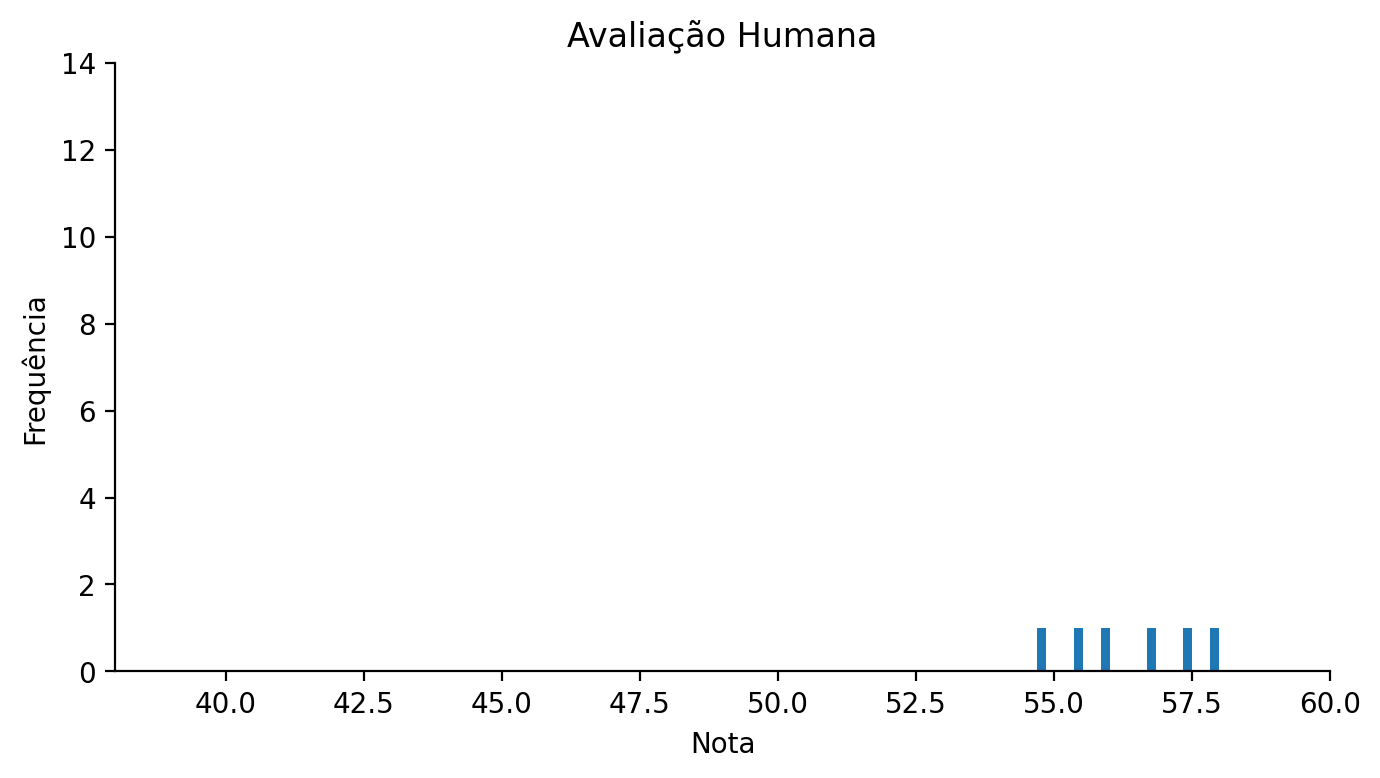

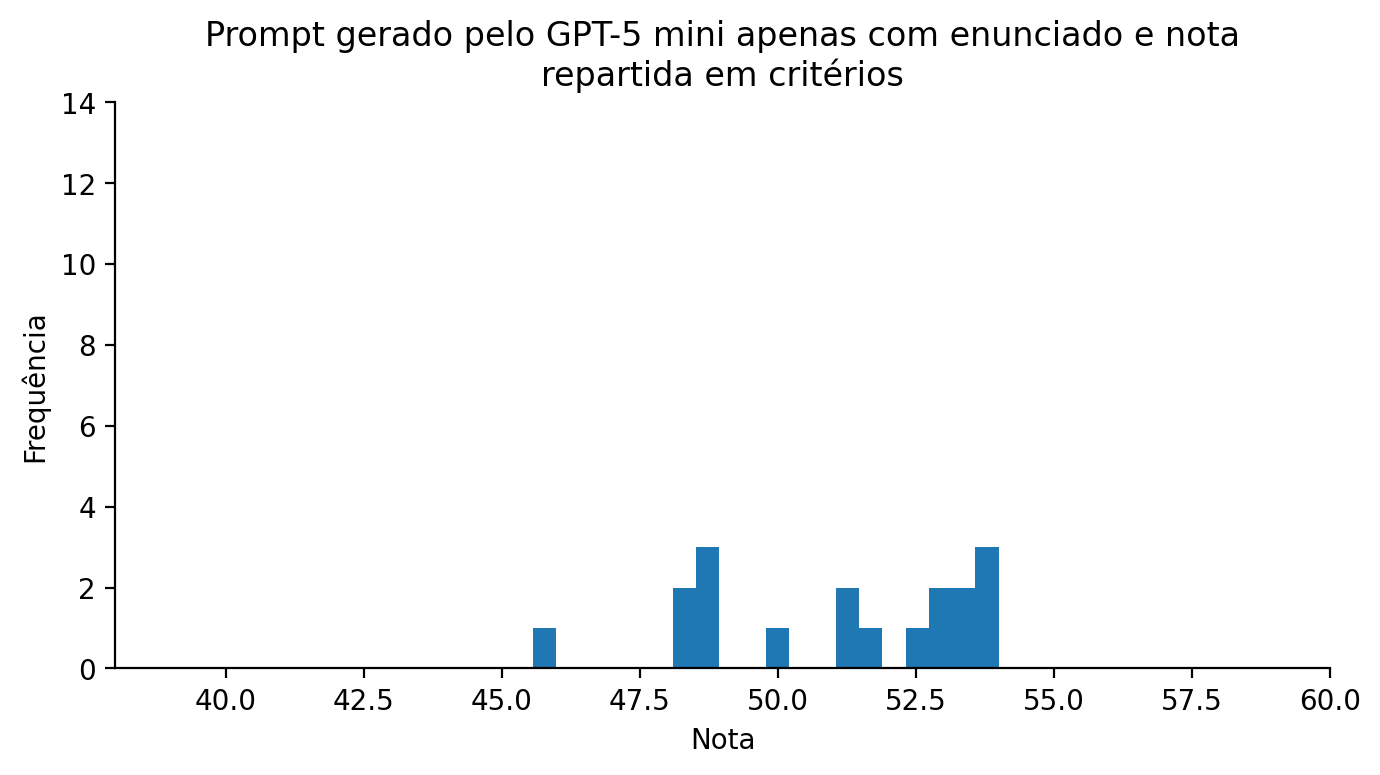

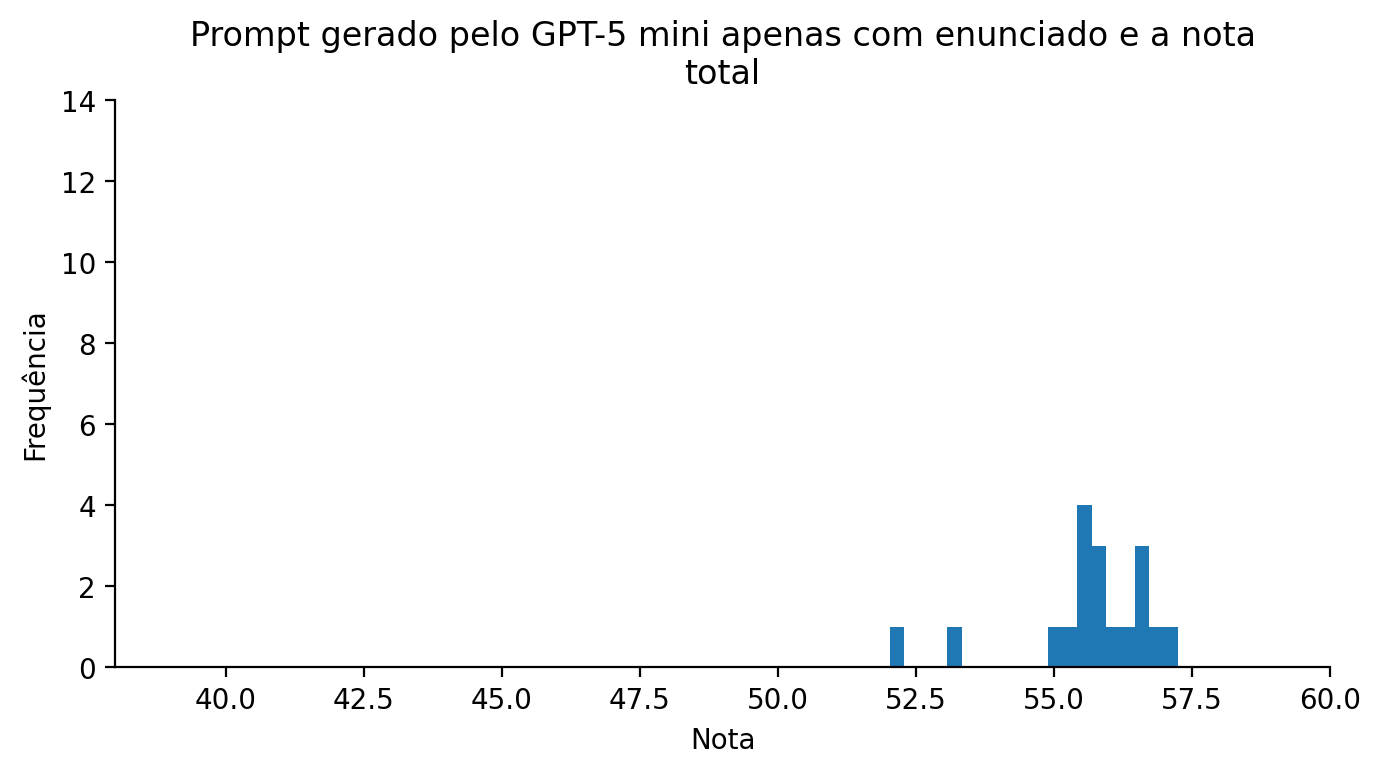

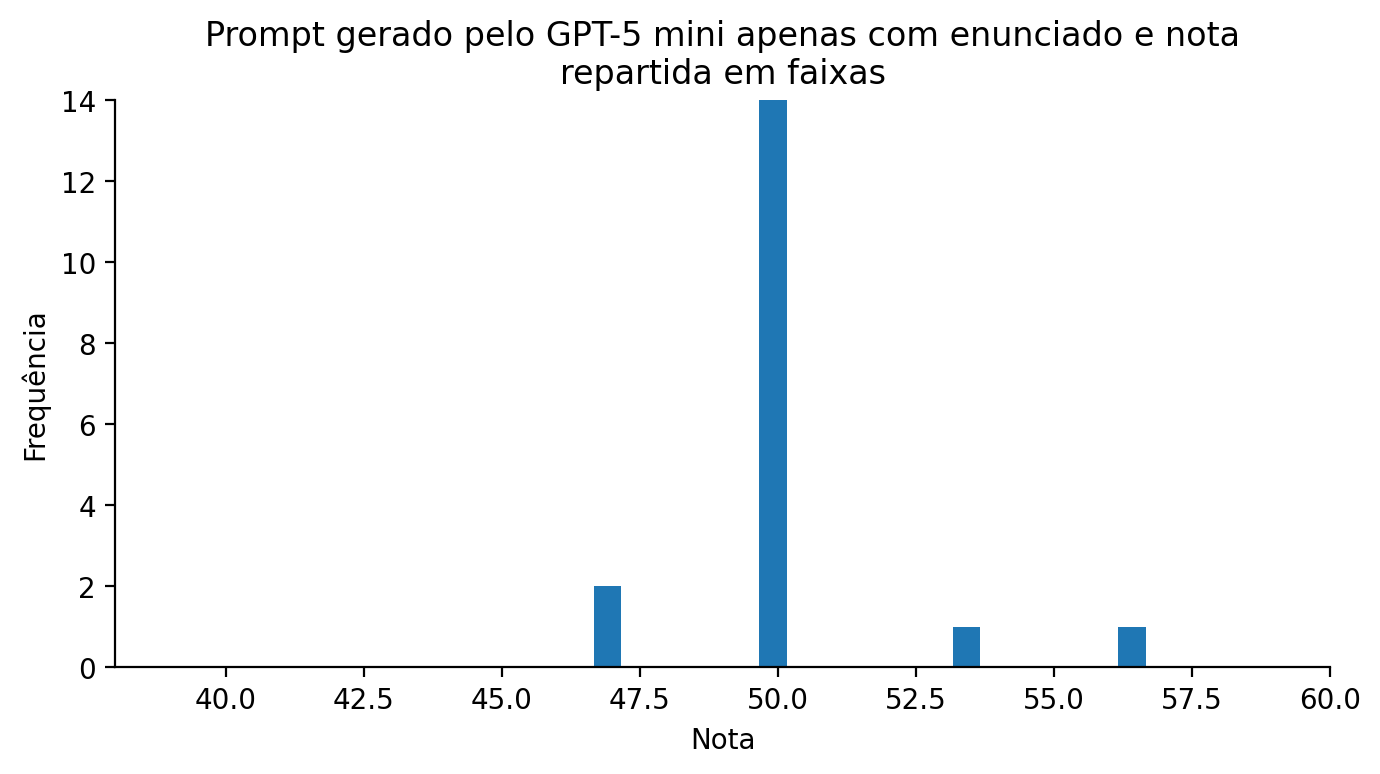

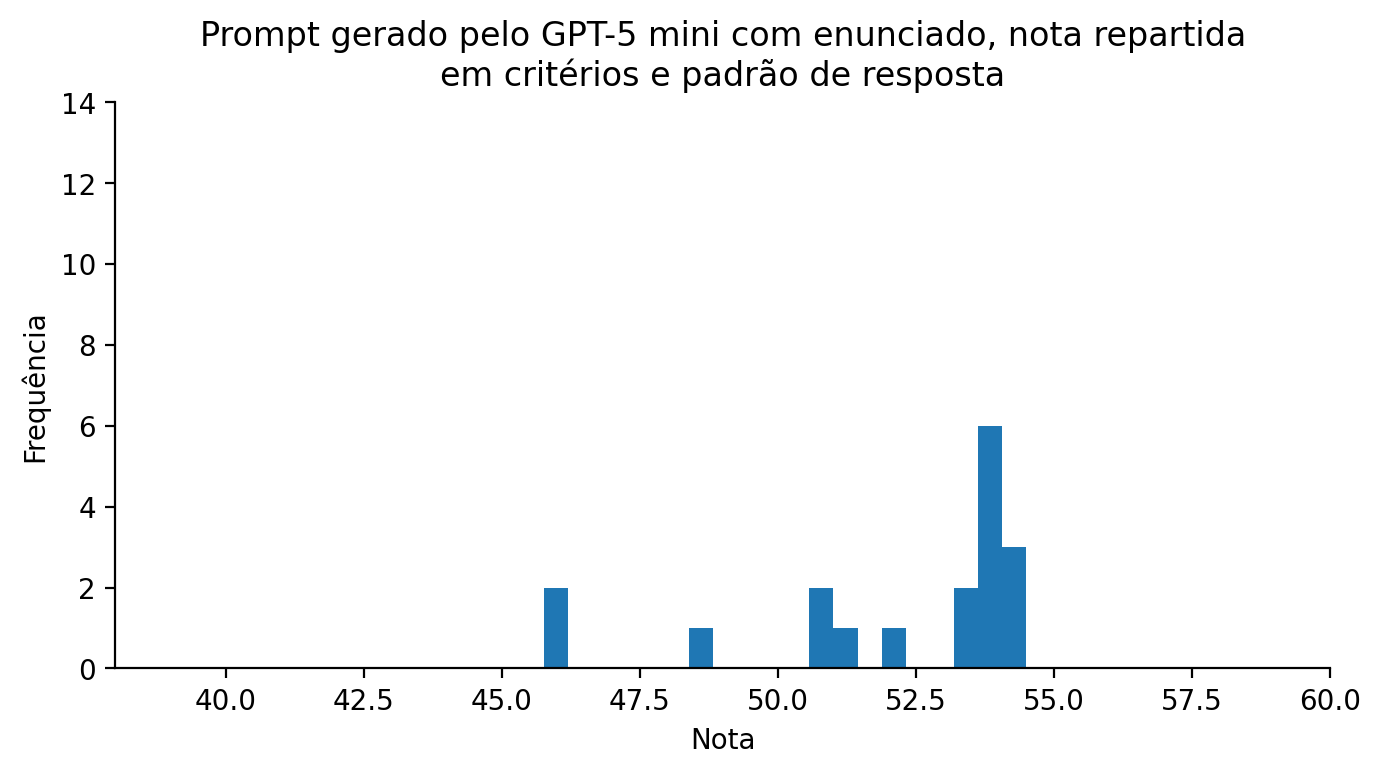

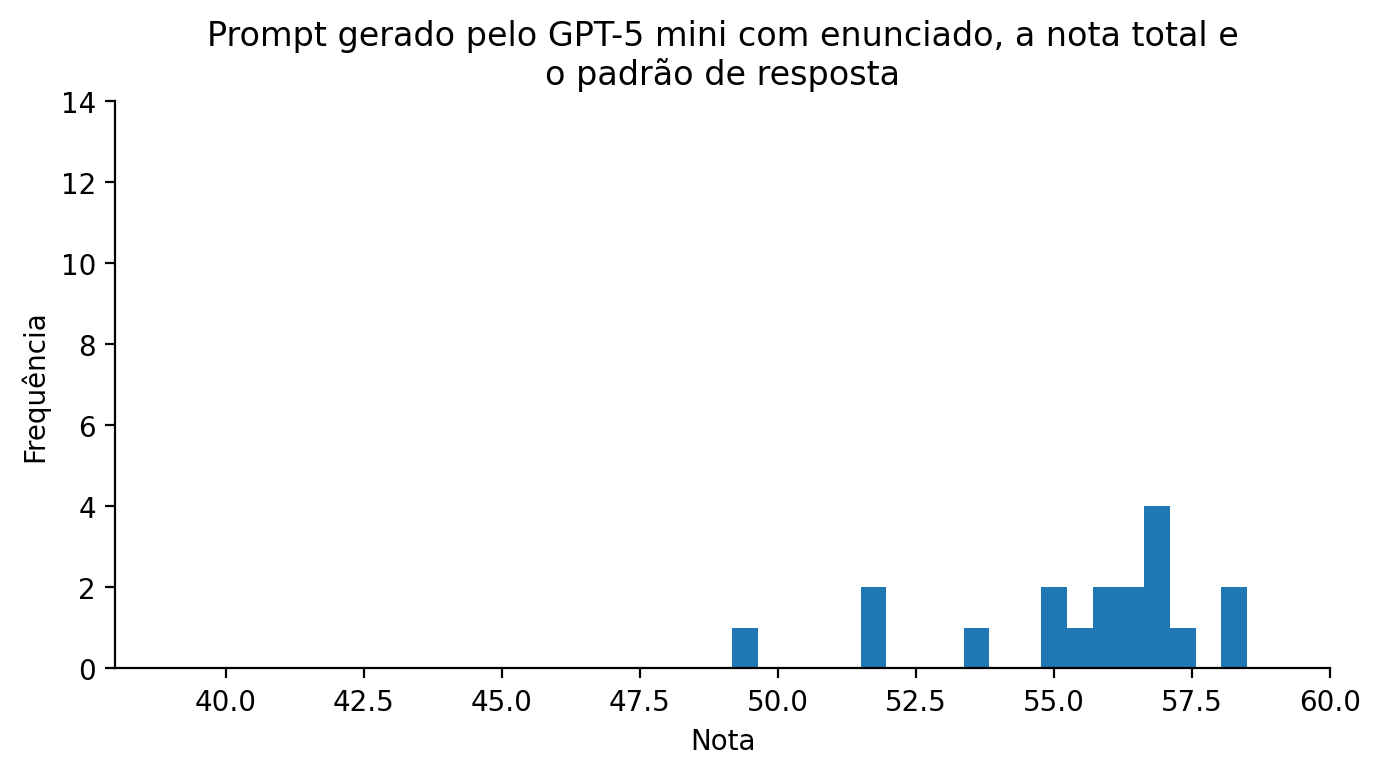

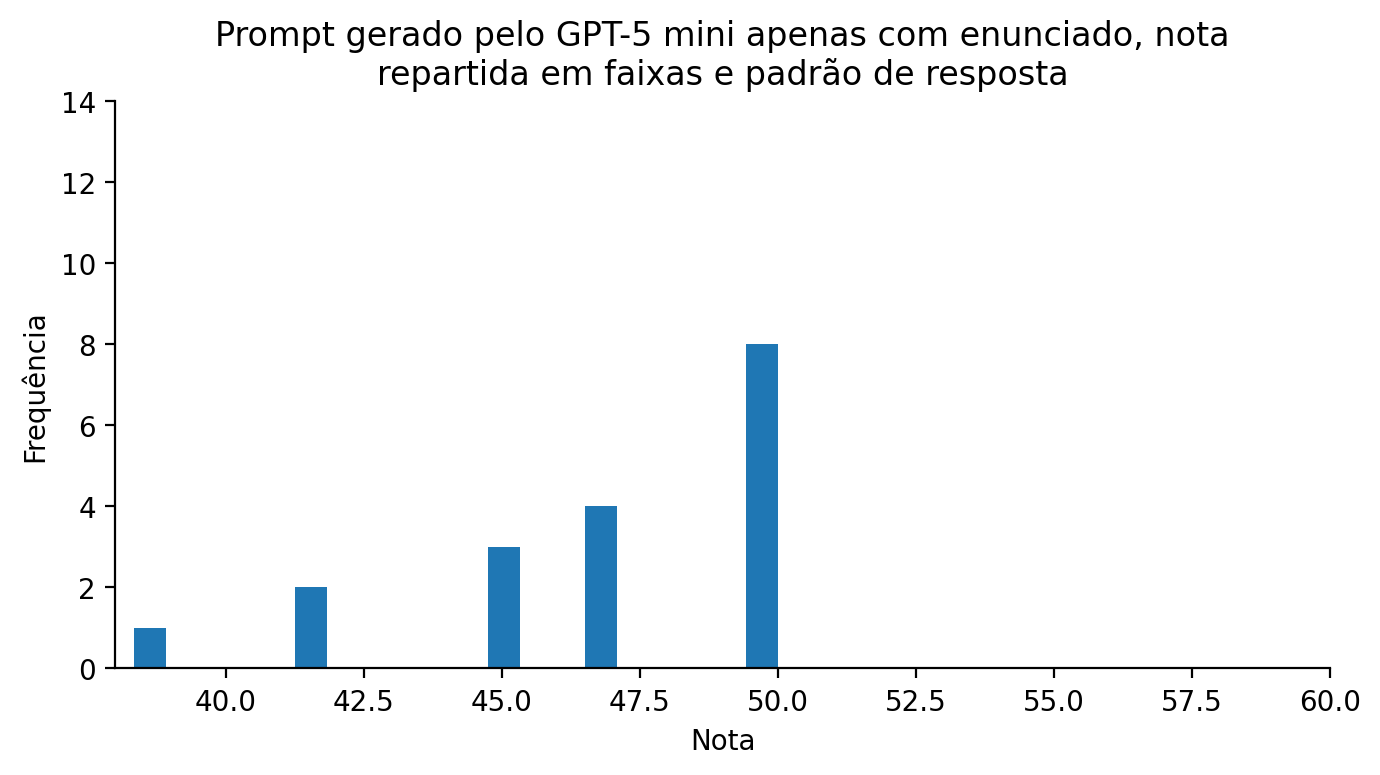

In [20]:
with open("/Users/gccasini/GitHub/diplomatrixbr-eval/prompt_testing/prompts.yaml", 'r', encoding='utf-8') as file:
    prompts_yaml = yaml.safe_load(file)
    prompts = prompts_yaml['prompts']

for i in [0, 7, 8, 9, 10, 11, 12]:

    if i == 0:
        subset = df_human
        title = "Avaliação Humana"
    else:
        subset = df_eval[df_eval['prompt'] == i]
        title = "\n".join(textwrap.wrap(prompts[i+1]["description"], width=60))
    plt.figure(figsize=(7, 4))

    subset['nota_final'].plot(
        kind='hist',
        bins=20,
        title=title,
        xlabel="Nota",
        ylabel="Frequência"
    )

    plt.xlim(38, 60)
    plt.ylim(0, 14)
    plt.gca().spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

In [ ]:
df_merged = df_eval.merge(
    df_human[["redacao", "nota_final"]].rename(columns={"nota_final": "nota_humana"}),
    on="redacao"
)

df_merged["se"] = (df_merged["nota_humana"] - df_merged["nota_final"])**2

df_merged["rmse"] = df_merged.groupby(
    ["judge", "prompt", "temp", "redacao"]
)["se"].transform("mean") ** 0.5

df_merged[:24]

,judge,prompt,temp,redacao,nota_final,1A,1B,1C,CGPL,num_errors,nota_humana,se,rmse
0,sabia-3.1,7,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,55.5,2.250000,1.5000
1,sabia-3.1,7,0.5,1,52.6333,8.6667,8.6667,18.0000,17.3000,2.3333,55.5,8.217969,2.8667
2,sabia-3.1,7,0.9,1,51.6333,8.6667,9.0000,17.3333,16.6333,2.3333,55.5,14.951369,3.8667
3,sabia-3.1,8,0.0,1,55.7500,NaN,NaN,NaN,NaN,0.0000,55.5,0.062500,0.2500
4,sabia-3.1,8,0.5,1,57.2500,NaN,NaN,NaN,NaN,0.3333,55.5,3.062500,1.7500
5,sabia-3.1,8,0.9,1,56.8333,NaN,NaN,NaN,NaN,0.6667,55.5,1.777689,1.3333
6,sabia-3.1,9,0.0,1,50.0000,NaN,NaN,NaN,NaN,0.0000,55.5,30.250000,5.5000
7,sabia-3.1,9,0.5,1,50.0000,NaN,NaN,NaN,NaN,0.0000,55.5,30.250000,5.5000
8,sabia-3.1,9,0.9,1,53.3333,NaN,NaN,NaN,NaN,0.0000,55.5,4.694589,2.1667
9,sabia-3.1,10,0.0,1,54.0000,9.0000,9.0000,18.0000,18.0000,0.0000,55.5,2.250000,1.5000


In [91]:
areas = {}

for (prompt, temp), group in df_merged.groupby(["prompt", "temp"]):  
    area = np.trapezoid(group["rmse"], group["redacao"])
    areas[(prompt, temp)] = prompt, temp, area.round(4)

df_area_sob_grafico = pd.DataFrame.from_dict(areas, orient='index', columns=['prompt', 'temp', 'area_rmse']).reset_index(drop=True)
df_area_sob_grafico = df_area_sob_grafico.sort_values("area_rmse")

prompt,temp,area_rmse
8,0.0,5.7917
8,0.5,6.7217
11,0.5,9.8333
8,0.9,10.1667
11,0.9,13.2083
11,0.0,14.1667
10,0.5,19.6499
10,0.0,22.0334
7,0.0,25.1000
7,0.5,25.6666

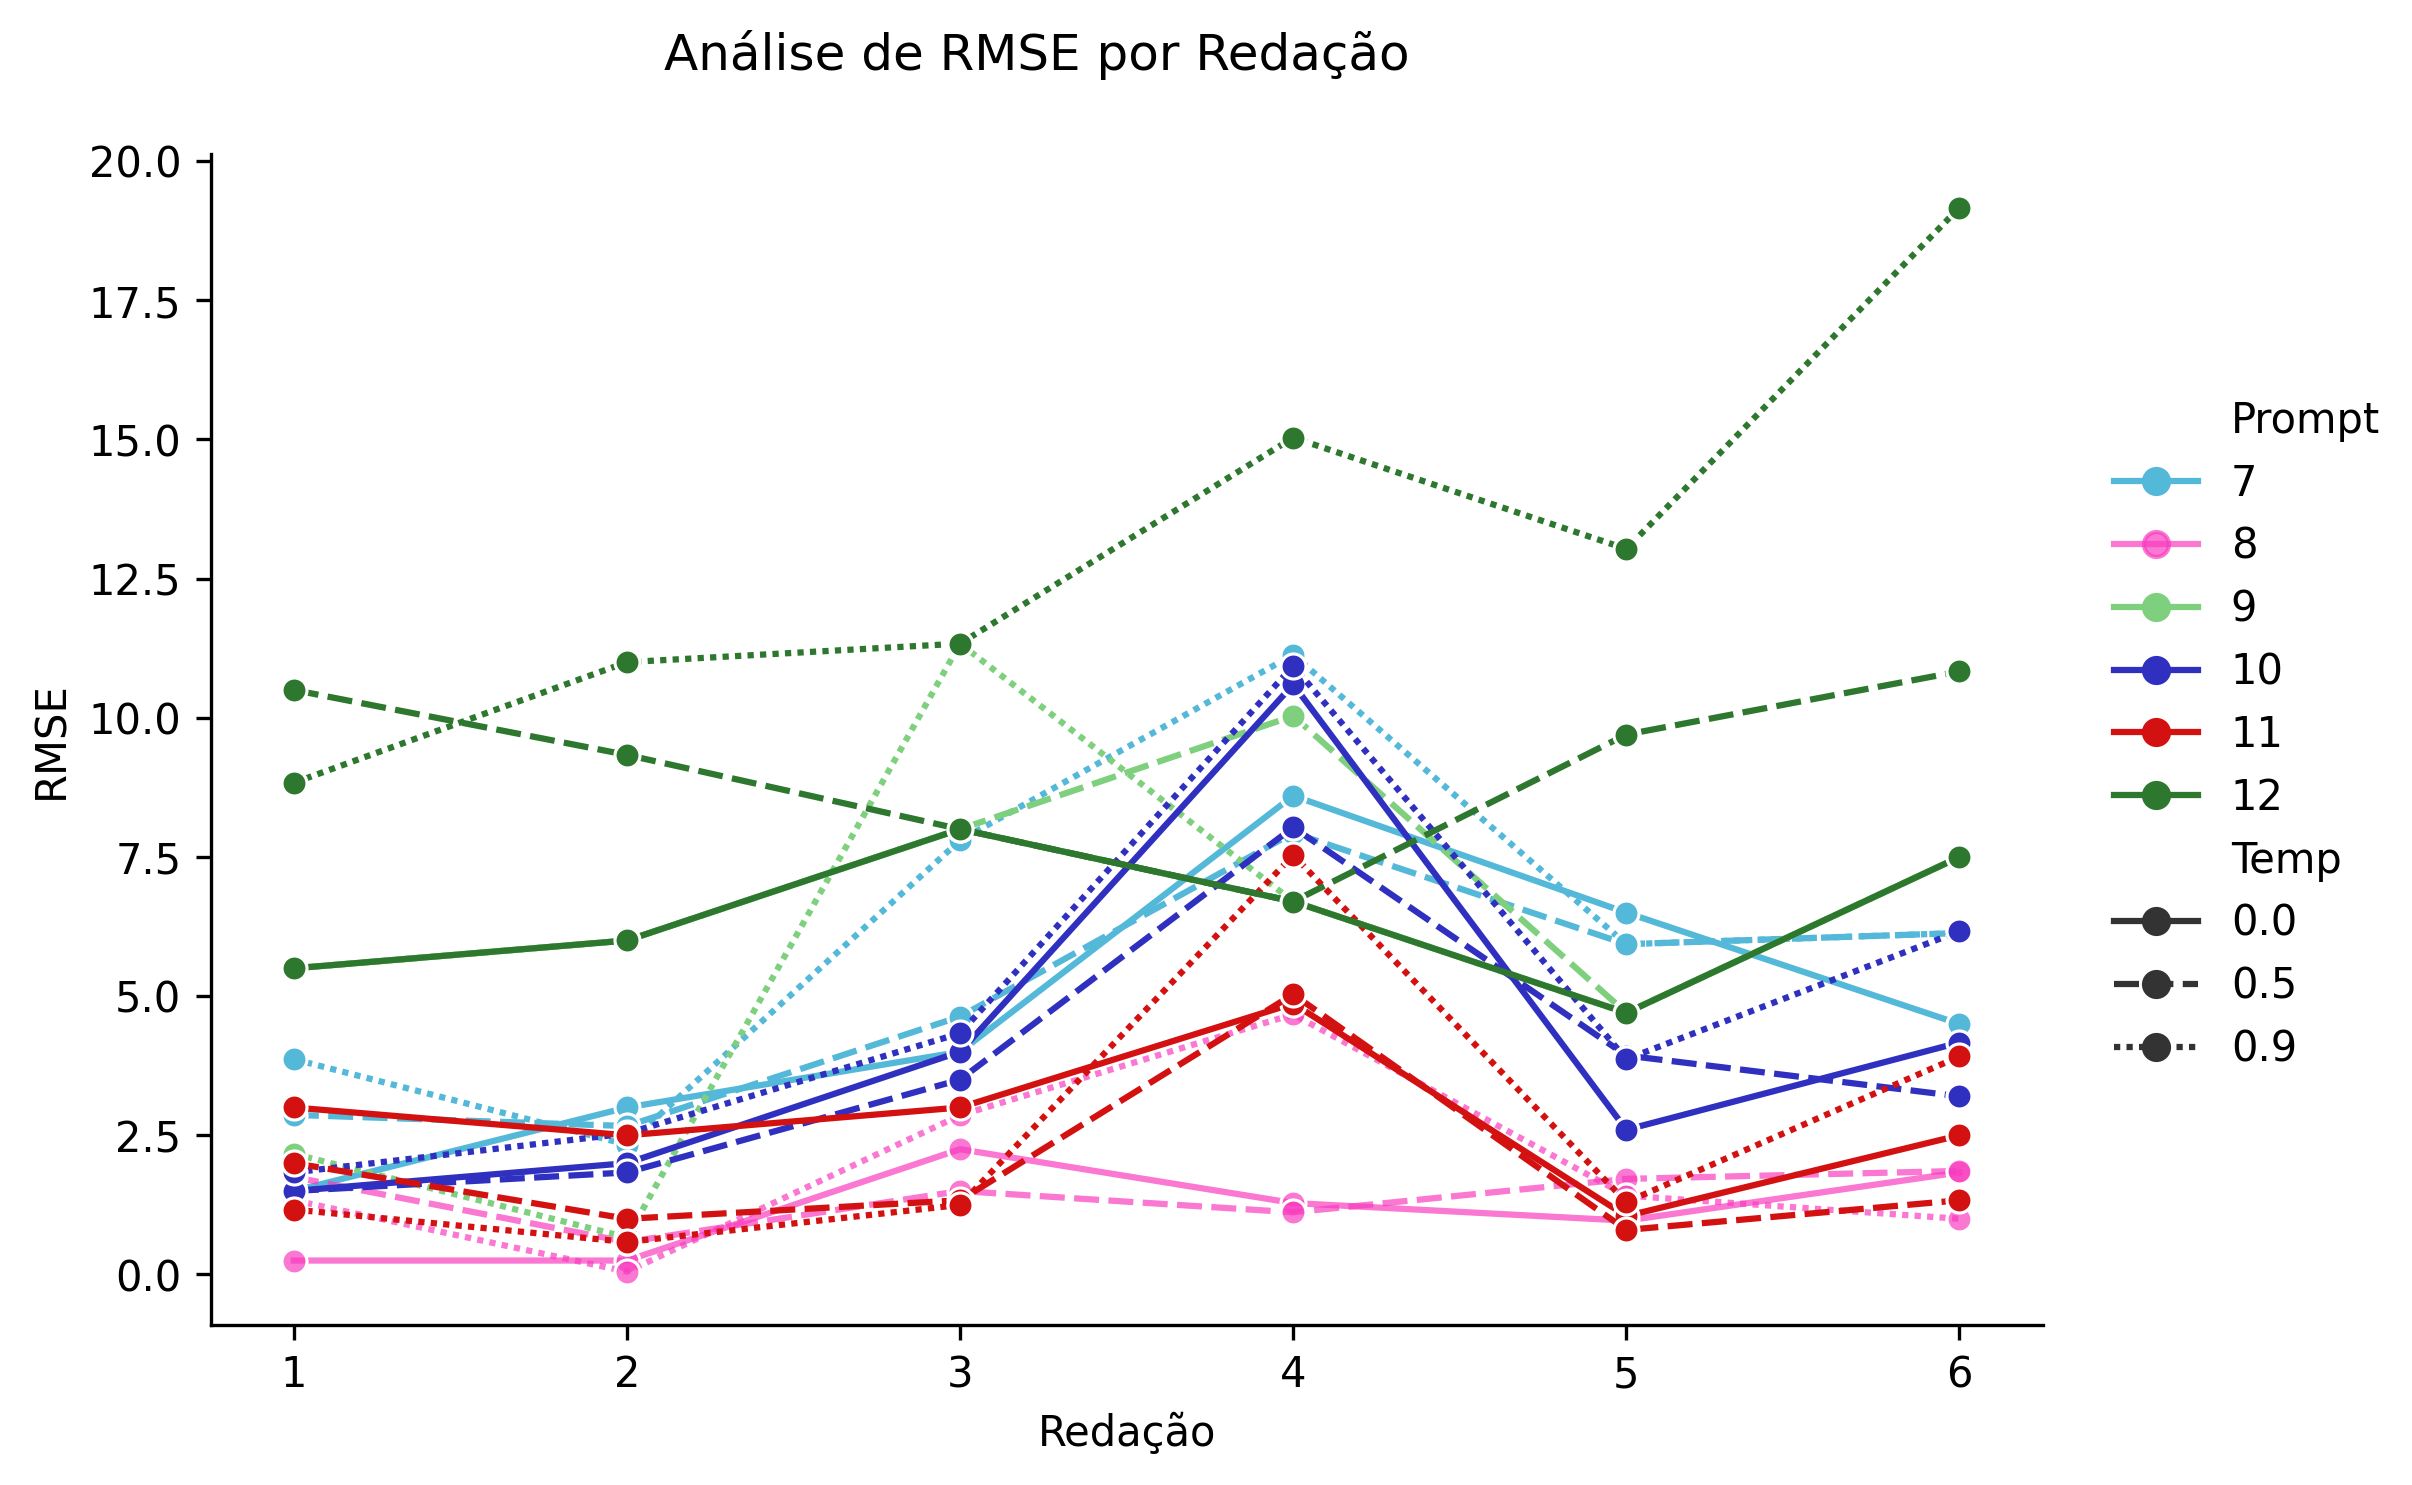

In [126]:
g = sns.relplot(
    data=df_merged,
    x="redacao",
    y="rmse",
    hue="prompt",
    style="temp",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
    palette = ["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"]
)

g._legend.set_bbox_to_anchor((1.15, 0.5))
g._legend.texts[0].set_text("Prompt")
g._legend.texts[7].set_text("Temp")

plt.suptitle("Análise de RMSE por Redação")
plt.tight_layout()
plt.xlabel("Redação")
plt.ylabel("RMSE")

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
buf.seek(0)
encoded = base64.b64encode(buf.read()).decode('utf-8')

html = f"""
<div style="display: flex; align-items: flex-start; gap: 30px;">
    <div style="flex: 1;">
        <img src="data:image/png;base64,{encoded}">
    </div>
    <div></div><br>
    <div style="flex: 0.8; align-self: center;">
        {df_area_sob_grafico.to_html(index=False)}
    </div>
</div>
"""

display(HTML(html))

plt.close()

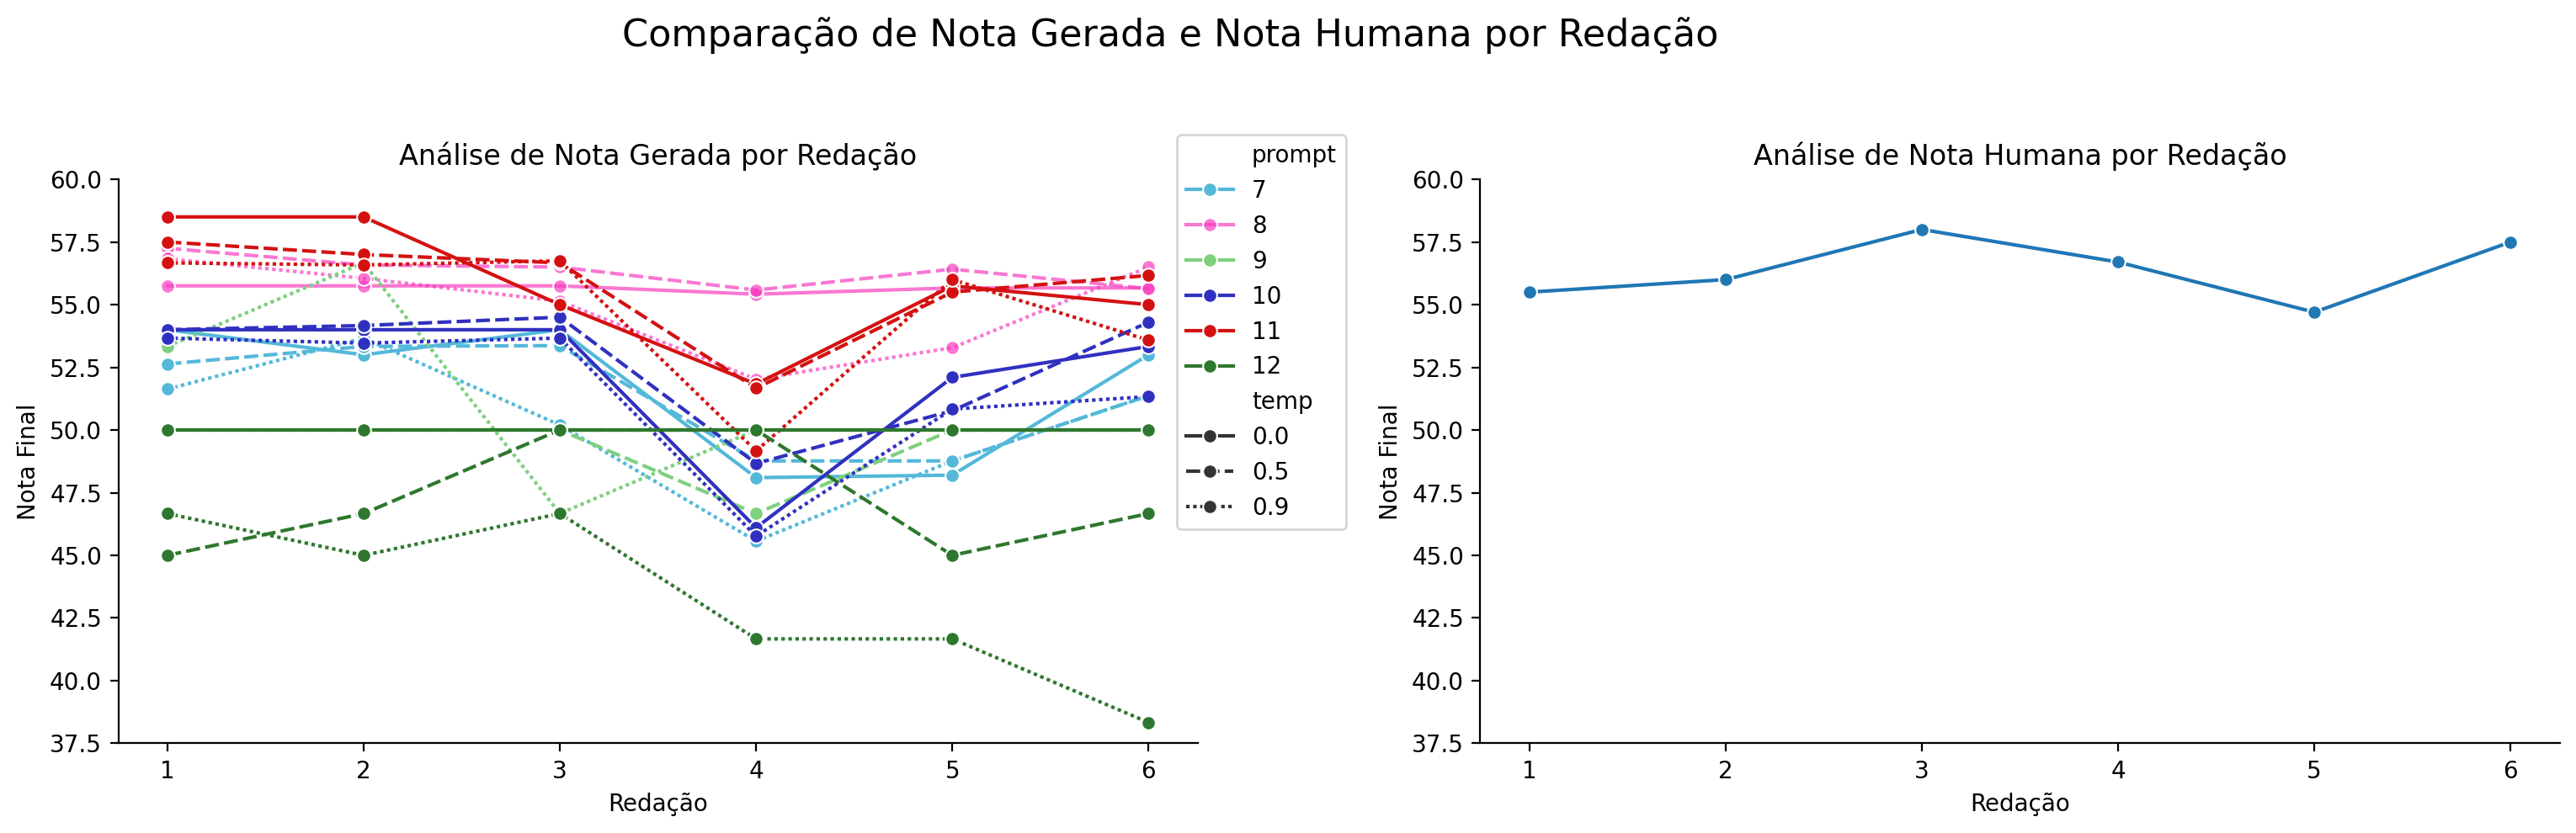

In [163]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=df_merged,
    x="redacao",
    y="nota_final",
    hue="prompt",
    style="temp",
    marker="o",
    palette=["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"],
    ax=axes[0]
)
axes[0].set_title("Análise de Nota Gerada por Redação")
axes[0].set_xlabel("Redação")
axes[0].set_ylabel("Nota Final")
axes[0].set_ylim(37.5, 60)
axes[0].legend(bbox_to_anchor=(0.97, 1.1), loc="upper left")
axes[0].spines[['top', 'right']].set_visible(False)

sns.lineplot(
    data=df_merged,
    x="redacao",
    y="nota_humana",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Análise de Nota Humana por Redação")
axes[1].set_xlabel("Redação")
axes[1].set_ylabel("Nota Final")
axes[1].set_ylim(37.5, 60)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle("Comparação de Nota Gerada e Nota Humana por Redação", fontsize=16)
plt.tight_layout(rect=[0, 0, 1.1, 0.95])
plt.show()


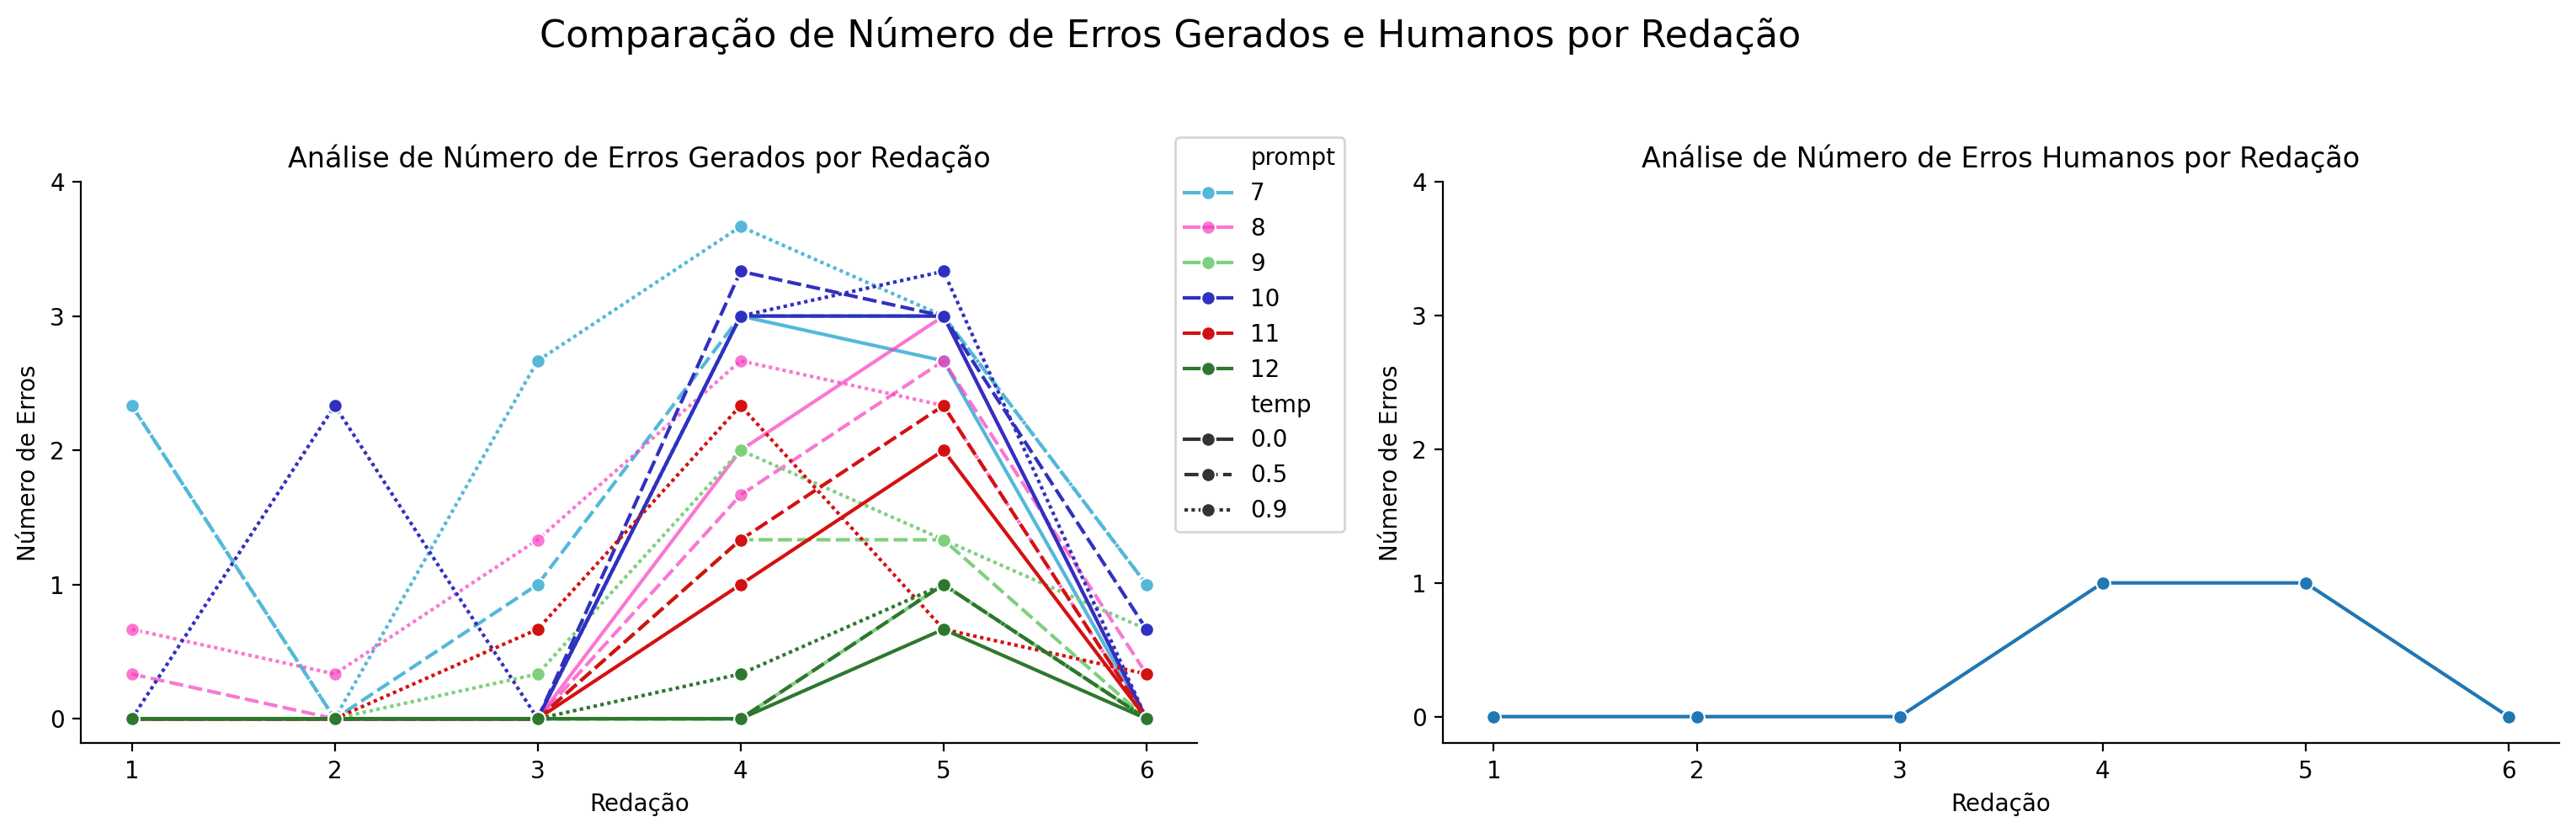

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=df_merged,
    x="redacao",
    y="num_errors",
    hue="prompt",
    style="temp",
    marker="o",
    palette=["#54B8D9", "#F83BBFB1", "#7ED07E", "#3030C0", "#D41111", "#2E772E"],
    ax=axes[0]
)
axes[0].set_title("Análise de Número de Erros Gerados por Redação")
axes[0].set_xlabel("Redação")
axes[0].set_ylabel("Número de Erros")
axes[0].set_yticks([0, 1, 2, 3, 4])
axes[0].legend(bbox_to_anchor=(0.97, 1.1), loc="upper left")
axes[0].spines[['top', 'right']].set_visible(False)

sns.lineplot(
    data=df_human,
    x="redacao",
    y="num_errors",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("Análise de Número de Erros Humanos por Redação")
axes[1].set_xlabel("Redação")
axes[1].set_ylabel("Número de Erros")
axes[1].set_yticks([0, 1, 2, 3, 4])
axes[1].set_ylim(-0.2, 4)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle("Comparação de Número de Erros Gerados e Humanos por Redação", fontsize=16)
plt.tight_layout(rect=[0, 0, 1.1, 0.95])
plt.show()
